# causal-learn Tutorial 00: Environment And Library Tour

This notebook starts the `causal-learn` tutorial series. The goal is not to learn one algorithm yet. The goal is to get oriented: what the library does, what assumptions causal discovery methods rely on, how graph outputs should be read, and how to run a small smoke test that proves the environment is ready.

`causal-learn` is mainly a **causal discovery** library. It helps estimate candidate graph structure from observational or interventional data. That makes it different from DoWhy and EconML: those libraries are usually used after the causal question or graph structure has been specified. Discovery is earlier and more assumption-sensitive, so the tutorial series will repeatedly emphasize diagnostics, stability, and cautious language.

## Learning Goals

By the end of this notebook, you should be able to:

- Verify that `causal-learn` is installed and importable from the current environment.
- Understand the main algorithm families exposed by the library.
- Explain the difference between discovery, identification, and effect estimation.
- Recognize common graph outputs such as DAGs, CPDAGs, PAGs, skeletons, and partially oriented edges.
- Generate a small synthetic dataset with a known causal graph.
- Run a first PC algorithm smoke test and compare the learned graph to the known graph.
- Save tables and figures in the same output style as the other tutorial folders.

## How This Tutorial Fits The Series

The rest of the `causal-learn` notebooks will go deep into specific algorithm families. Notebook 00 gives the shared vocabulary and environment checks those notebooks will reuse.

A useful way to think about the series is:

- Early notebooks teach graph objects, synthetic data, and independence tests.
- Middle notebooks teach PC, FCI, CD-NOD, GES, LiNGAM, ANM, PNL, permutation methods, time-series tools, and hidden-representation methods.
- Final notebooks focus on benchmarking, stability, an end-to-end case study, and reporting limitations.

The important mindset: discovered graphs are usually **candidate structures**, not automatic causal truth.

## Setup

This cell imports core packages, configures plotting, creates output folders, and checks whether `causal-learn` is importable. The package is installed under the Python module name `causallearn`, even though the package name is written as `causal-learn`.

In [1]:
from pathlib import Path
import os
import platform
import sys
import warnings
from importlib import metadata
from importlib.util import find_spec

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "causal_learn":
    NOTEBOOK_DIR = Path("notebooks/tutorials/causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [FIGURE_DIR, TABLE_DIR, REPORT_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str((OUTPUT_DIR / "matplotlib_cache").resolve()))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*The default value of.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

try:
    import causallearn
    CAUSAL_LEARN_AVAILABLE = True
    try:
        CAUSAL_LEARN_VERSION = metadata.version("causal-learn")
    except metadata.PackageNotFoundError:
        CAUSAL_LEARN_VERSION = getattr(causallearn, "__version__", "available")
except Exception as exc:
    causallearn = None
    CAUSAL_LEARN_AVAILABLE = False
    CAUSAL_LEARN_VERSION = f"not available: {exc}"

RANDOM_STATE = 20260430
rng = np.random.default_rng(RANDOM_STATE)
NOTEBOOK_PREFIX = "00"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Python: {sys.version.split()[0]}")
print(f"causal-learn importable: {CAUSAL_LEARN_AVAILABLE}")
print(f"causal-learn version/status: {CAUSAL_LEARN_VERSION}")
print(f"Notebook directory: {NOTEBOOK_DIR}")

Python: 3.13.12
causal-learn importable: True
causal-learn version/status: 0.1.4.5
Notebook directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/causal_learn


If `causal-learn importable` is `True`, the environment can run the live examples in this notebook. If it is `False`, the tables and explanatory sections still make sense, but the algorithm cells should be rerun after installing `causal-learn`.

## Package Version Snapshot

Causal discovery results can be sensitive to software versions, especially when graph classes, scoring functions, and independence tests change. This cell records the core package versions used by the tutorial run.

In [2]:
def package_version(package_name):
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_table = pd.DataFrame(
    [
        {"package": "python", "version": platform.python_version(), "role": "Runtime."},
        {"package": "causal-learn", "version": package_version("causal-learn"), "role": "Causal discovery algorithms."},
        {"package": "numpy", "version": package_version("numpy"), "role": "Numerical arrays and simulation."},
        {"package": "pandas", "version": package_version("pandas"), "role": "Tabular data handling."},
        {"package": "scipy", "version": package_version("scipy"), "role": "Statistical utilities."},
        {"package": "scikit-learn", "version": package_version("scikit-learn"), "role": "Scaling and helper models."},
        {"package": "networkx", "version": package_version("networkx"), "role": "Teaching graph visualization."},
        {"package": "matplotlib", "version": package_version("matplotlib"), "role": "Static plotting."},
        {"package": "seaborn", "version": package_version("seaborn"), "role": "Statistical plotting."},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)

,package,version,role
0,python,3.13.12,Runtime.
1,causal-learn,0.1.4.5,Causal discovery algorithms.
2,numpy,2.4.4,Numerical arrays and simulation.
3,pandas,3.0.2,Tabular data handling.
4,scipy,1.17.1,Statistical utilities.
5,scikit-learn,1.6.1,Scaling and helper models.
6,networkx,3.6.1,Teaching graph visualization.
7,matplotlib,3.10.9,Static plotting.
8,seaborn,0.13.2,Statistical plotting.


The package snapshot is a small reproducibility habit. When a discovered graph changes after an environment update, this table helps separate methodological changes from software changes.

## Discovery Versus Estimation

Before using `causal-learn`, it is important to separate three related tasks: discovering graph structure, identifying an estimand, and estimating an effect. `causal-learn` mainly helps with the first task.

In [3]:
workflow_comparison = pd.DataFrame(
    [
        {
            "task": "Causal discovery",
            "typical_question": "Which variables may be directly connected in a causal graph?",
            "typical_output": "Candidate DAG, CPDAG, PAG, or partially oriented graph.",
            "common_tools": "causal-learn, Tetrad, Tigramite, gCastle.",
        },
        {
            "task": "Identification",
            "typical_question": "Given a graph and assumptions, what estimand identifies the causal effect?",
            "typical_output": "Backdoor, frontdoor, IV, mediation, or other estimand.",
            "common_tools": "DoWhy, graphical criteria, domain reasoning.",
        },
        {
            "task": "Effect estimation",
            "typical_question": "How large is the effect, and how does it vary across units?",
            "typical_output": "ATE, CATE, intervals, policy value, sensitivity checks.",
            "common_tools": "EconML, DoWhy estimators, statsmodels, sklearn-style models.",
        },
    ]
)
workflow_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discovery_vs_estimation.csv", index=False)
display(workflow_comparison)

,task,typical_question,typical_output,common_tools
0,Causal discovery,Which variables may be directly connected in a...,"Candidate DAG, CPDAG, PAG, or partially orient...","causal-learn, Tetrad, Tigramite, gCastle."
1,Identification,"Given a graph and assumptions, what estimand i...","Backdoor, frontdoor, IV, mediation, or other e...","DoWhy, graphical criteria, domain reasoning."
2,Effect estimation,"How large is the effect, and how does it vary ...","ATE, CATE, intervals, policy value, sensitivit...","EconML, DoWhy estimators, statsmodels, sklearn..."


This distinction keeps expectations healthy. Discovery can suggest candidate structure, but a discovered graph still needs domain review before it becomes the basis for effect estimation or decisions.

## Library Capability Map

`causal-learn` includes several families of methods. This table gives a high-level map so later notebooks have a shared reference point.

In [4]:
capability_map = pd.DataFrame(
    [
        {
            "family": "Constraint-based discovery",
            "examples": "PC, FCI, CD-NOD",
            "core_idea": "Use conditional independence tests to remove and orient edges.",
            "best_when": "The conditional independence test is well matched to the data and sample size is adequate.",
        },
        {
            "family": "Score-based discovery",
            "examples": "GES, exact search",
            "core_idea": "Search over graph structures using a decomposable score such as BIC or BDeu.",
            "best_when": "A scoring assumption is credible and the variable set is not too large for the search strategy.",
        },
        {
            "family": "Functional causal models",
            "examples": "LiNGAM, ANM, PNL",
            "core_idea": "Use functional or noise assumptions to identify causal direction beyond Markov equivalence.",
            "best_when": "Linearity, non-Gaussianity, additive-noise, or post-nonlinear assumptions are scientifically plausible.",
        },
        {
            "family": "Permutation-based discovery",
            "examples": "GRaSP, BOSS",
            "core_idea": "Search over variable orderings or permutations that imply graph structures.",
            "best_when": "Ordering-based search is computationally feasible and useful for the graph size.",
        },
        {
            "family": "Hidden causal representation",
            "examples": "GIN",
            "core_idea": "Use constraints designed for latent causal structure and hidden variables.",
            "best_when": "The problem is explicitly about hidden structure rather than only observed-variable DAGs.",
        },
        {
            "family": "Time-series discovery",
            "examples": "Granger-style tools, VAR-LiNGAM",
            "core_idea": "Use lagged temporal structure to separate past causes from future outcomes.",
            "best_when": "Variables are measured repeatedly and temporal ordering is meaningful.",
        },
    ]
)
capability_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_capability_map.csv", index=False)
display(capability_map)

,family,examples,core_idea,best_when
0,Constraint-based discovery,"PC, FCI, CD-NOD",Use conditional independence tests to remove a...,The conditional independence test is well matc...
1,Score-based discovery,"GES, exact search",Search over graph structures using a decomposa...,A scoring assumption is credible and the varia...
2,Functional causal models,"LiNGAM, ANM, PNL",Use functional or noise assumptions to identif...,"Linearity, non-Gaussianity, additive-noise, or..."
3,Permutation-based discovery,"GRaSP, BOSS",Search over variable orderings or permutations...,Ordering-based search is computationally feasi...
4,Hidden causal representation,GIN,Use constraints designed for latent causal str...,The problem is explicitly about hidden structu...
5,Time-series discovery,"Granger-style tools, VAR-LiNGAM",Use lagged temporal structure to separate past...,Variables are measured repeatedly and temporal...


The method family should be chosen from assumptions, not popularity. For example, FCI is more appropriate than PC when latent confounding is plausible, while LiNGAM needs stronger functional assumptions than PC.

## Import Capability Check

This cell tests whether the main modules used in the series can be imported. It does not prove every method will work for every dataset, but it catches missing optional components early.

In [5]:
module_checks = []
modules_to_check = [
    ("PC", "causallearn.search.ConstraintBased.PC", "Constraint-based discovery for causally sufficient settings."),
    ("FCI", "causallearn.search.ConstraintBased.FCI", "Constraint-based discovery allowing latent confounders."),
    ("CD-NOD", "causallearn.search.ConstraintBased.CDNOD", "Discovery under nonstationary or heterogeneous data."),
    ("GES", "causallearn.search.ScoreBased.GES", "Greedy score-based graph search."),
    ("ExactSearch", "causallearn.search.ScoreBased.ExactSearch", "Exact score-based search for small graphs."),
    ("LiNGAM", "causallearn.search.FCMBased.lingam", "Linear non-Gaussian functional causal models."),
    ("ANM", "causallearn.search.FCMBased.ANM.ANM", "Additive-noise model tools."),
    ("PNL", "causallearn.search.FCMBased.PNL.PNL", "Post-nonlinear model tools."),
    ("GRaSP", "causallearn.search.PermutationBased.GRaSP", "Permutation-based discovery."),
    ("BOSS", "causallearn.search.PermutationBased.BOSS", "Permutation-based discovery."),
    ("GIN", "causallearn.search.HiddenCausal.GIN.GIN", "Hidden causal representation discovery."),
    ("GraphUtils", "causallearn.utils.GraphUtils", "Graph output utilities."),
]

for label, module_name, role in modules_to_check:
    spec = find_spec(module_name)
    module_checks.append(
        {
            "component": label,
            "module": module_name,
            "available": spec is not None,
            "role": role,
        }
    )

module_check_table = pd.DataFrame(module_checks)
module_check_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_module_capability_check.csv", index=False)
display(module_check_table)

,component,module,available,role
0,PC,causallearn.search.ConstraintBased.PC,True,Constraint-based discovery for causally suffic...
1,FCI,causallearn.search.ConstraintBased.FCI,True,Constraint-based discovery allowing latent con...
2,CD-NOD,causallearn.search.ConstraintBased.CDNOD,True,Discovery under nonstationary or heterogeneous...
3,GES,causallearn.search.ScoreBased.GES,True,Greedy score-based graph search.
4,ExactSearch,causallearn.search.ScoreBased.ExactSearch,True,Exact score-based search for small graphs.
5,LiNGAM,causallearn.search.FCMBased.lingam,True,Linear non-Gaussian functional causal models.
6,ANM,causallearn.search.FCMBased.ANM.ANM,True,Additive-noise model tools.
7,PNL,causallearn.search.FCMBased.PNL.PNL,True,Post-nonlinear model tools.
8,GRaSP,causallearn.search.PermutationBased.GRaSP,True,Permutation-based discovery.
9,BOSS,causallearn.search.PermutationBased.BOSS,True,Permutation-based discovery.


The available modules form the practical menu for the rest of the tutorial. Some algorithms may still require extra assumptions, careful preprocessing, or smaller datasets even when the import succeeds.

## Core Assumptions To Track

Causal discovery methods are assumption-heavy. The next table collects assumptions that will appear repeatedly across the series.

In [6]:
assumption_table = pd.DataFrame(
    [
        {
            "assumption": "Causal Markov condition",
            "plain_language": "A variable is independent of its non-effects after conditioning on its direct causes.",
            "why_it_matters": "It links graph separation to statistical independence patterns.",
        },
        {
            "assumption": "Faithfulness",
            "plain_language": "Observed independencies come from the graph structure, not exact parameter cancellation.",
            "why_it_matters": "Constraint-based methods can miss or add edges when faithfulness fails.",
        },
        {
            "assumption": "Causal sufficiency",
            "plain_language": "There are no unobserved common causes among the measured variables.",
            "why_it_matters": "PC relies on this more strongly than FCI-style methods.",
        },
        {
            "assumption": "Independent and identically distributed rows",
            "plain_language": "Rows are sampled from the same stable distribution without temporal dependence.",
            "why_it_matters": "Standard tabular tests can fail when data are time dependent or nonstationary.",
        },
        {
            "assumption": "Correct test or score choice",
            "plain_language": "The independence test or score matches the data type and distribution well enough.",
            "why_it_matters": "A poor test can produce a poor graph even when causal assumptions are reasonable.",
        },
        {
            "assumption": "No major measurement leakage",
            "plain_language": "Variables are measured at the intended time and do not include future information.",
            "why_it_matters": "Leaky variables can create graph structure that looks predictive but is causally invalid.",
        },
    ]
)
assumption_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_core_assumptions.csv", index=False)
display(assumption_table)

,assumption,plain_language,why_it_matters
0,Causal Markov condition,A variable is independent of its non-effects a...,It links graph separation to statistical indep...
1,Faithfulness,Observed independencies come from the graph st...,Constraint-based methods can miss or add edges...
2,Causal sufficiency,There are no unobserved common causes among th...,PC relies on this more strongly than FCI-style...
3,Independent and identically distributed rows,Rows are sampled from the same stable distribu...,Standard tabular tests can fail when data are ...
4,Correct test or score choice,The independence test or score matches the dat...,A poor test can produce a poor graph even when...
5,No major measurement leakage,Variables are measured at the intended time an...,Leaky variables can create graph structure tha...


A graph output is only as credible as the assumptions behind it. Later notebooks will make these assumptions concrete by changing data-generating processes and watching graph recovery change.

## Graph Vocabulary

Discovery outputs are not always fully directed DAGs. This vocabulary table will make later outputs easier to read.

In [7]:
graph_vocabulary = pd.DataFrame(
    [
        ("DAG", "Directed acyclic graph", "A graph with directed edges and no directed cycles."),
        ("Skeleton", "Adjacency pattern", "The undirected edge structure before directions are considered."),
        ("V-structure", "Collider pattern", "A pattern like A -> C <- B where A and B are not adjacent."),
        ("CPDAG", "Completed partially directed acyclic graph", "Represents a Markov equivalence class of DAGs."),
        ("PAG", "Partial ancestral graph", "Represents possible ancestral relations when hidden confounding may exist."),
        ("Circle endpoint", "Unresolved edge mark", "Used in PAGs when orientation is not fully determined."),
        ("Markov equivalence", "Same independence model", "Different DAGs can imply the same observed conditional independencies."),
        ("SHD", "Structural Hamming distance", "A graph-difference count used in benchmarks."),
    ],
    columns=["term", "short_name", "meaning"],
)
graph_vocabulary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_graph_vocabulary.csv", index=False)
display(graph_vocabulary)

,term,short_name,meaning
0,DAG,Directed acyclic graph,A graph with directed edges and no directed cy...
1,Skeleton,Adjacency pattern,The undirected edge structure before direction...
2,V-structure,Collider pattern,A pattern like A -> C <- B where A and B are n...
3,CPDAG,Completed partially directed acyclic graph,Represents a Markov equivalence class of DAGs.
4,PAG,Partial ancestral graph,Represents possible ancestral relations when h...
5,Circle endpoint,Unresolved edge mark,Used in PAGs when orientation is not fully det...
6,Markov equivalence,Same independence model,Different DAGs can imply the same observed con...
7,SHD,Structural Hamming distance,A graph-difference count used in benchmarks.


The key idea is that uncertainty in edge direction is normal. A partially oriented graph is often the honest output, not a failure.

## Teaching DAG For The Smoke Test

The first executable example uses a small known DAG with six variables. We keep the graph simple enough to inspect by eye but rich enough to include a collider and downstream pathways.

In [8]:
node_names = ["need", "intent", "match", "engagement", "renewal", "support"]
true_edges = [
    ("need", "match"),
    ("intent", "match"),
    ("match", "engagement"),
    ("intent", "renewal"),
    ("engagement", "renewal"),
    ("engagement", "support"),
]

true_graph = nx.DiGraph()
true_graph.add_nodes_from(node_names)
true_graph.add_edges_from(true_edges)

true_edge_table = pd.DataFrame(true_edges, columns=["cause", "effect"])
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_dag_edges.csv", index=False)
display(true_edge_table)

,cause,effect
0,need,match
1,intent,match
2,match,engagement
3,intent,renewal
4,engagement,renewal
5,engagement,support


The graph says that `need` and `intent` both affect `match`, `match` drives `engagement`, and engagement affects later renewal and support outcomes. This is a teaching graph, not a claim about a real product system.

## Draw The True DAG

A fixed layout makes it easier to compare the true graph and the learned graph later. The arrows in this figure represent the data-generating structure used by the simulation.

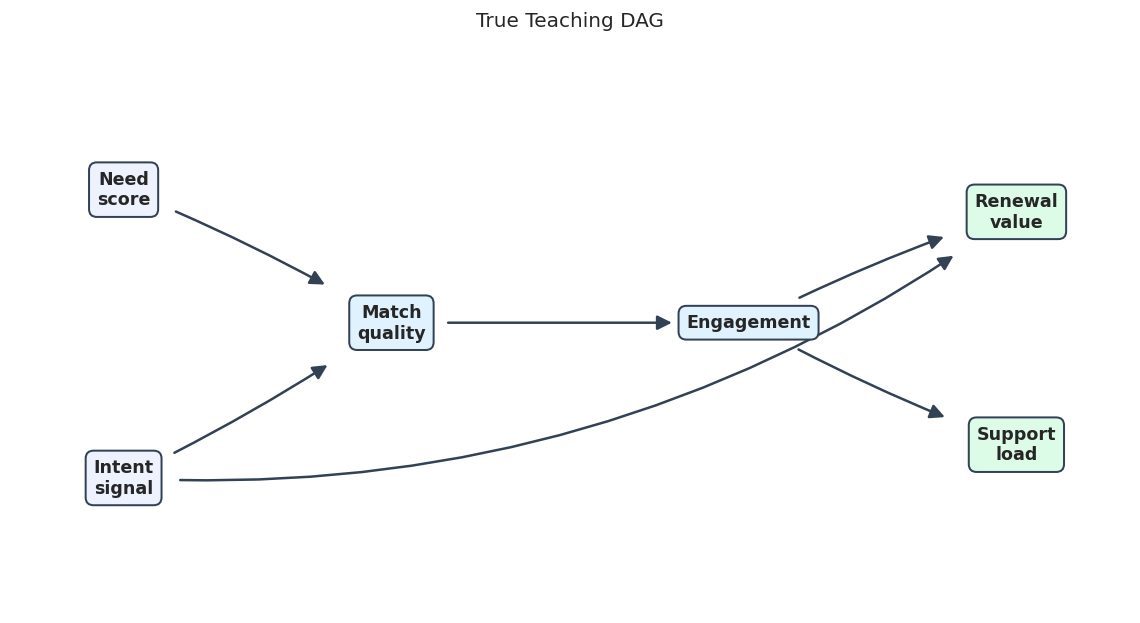

In [9]:
# The causal-learn tutorial uses the same DAG visual language as the DoWhy
# tutorial: wide white canvas, rounded pastel boxes, bold labels, and dark
# annotation arrows. Drawing arrows manually keeps arrowheads clear of boxes.
node_positions = {
    "need": (0.10, 0.76),
    "intent": (0.10, 0.24),
    "match": (0.34, 0.52),
    "engagement": (0.66, 0.52),
    "renewal": (0.90, 0.72),
    "support": (0.90, 0.30),
}

node_labels = {
    "need": "Need\nscore",
    "intent": "Intent\nsignal",
    "match": "Match\nquality",
    "engagement": "Engagement",
    "renewal": "Renewal\nvalue",
    "support": "Support\nload",
}

node_colors = {
    "need": "#eef2ff",
    "intent": "#eef2ff",
    "match": "#e0f2fe",
    "engagement": "#e0f2fe",
    "renewal": "#dcfce7",
    "support": "#dcfce7",
}

edge_radii = {
    ("need", "match"): -0.04,
    ("intent", "match"): 0.04,
    ("match", "engagement"): 0.00,
    ("engagement", "renewal"): -0.04,
    ("engagement", "support"): 0.04,
    ("intent", "renewal"): 0.18,
}


def draw_teaching_style_graph(edge_table, title, path, edge_radii=None):
    """Draw a causal graph using the shared tutorial DAG style."""
    edge_radii = edge_radii or {}
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()

    for row in edge_table.itertuples(index=False):
        source = row.source
        target = row.target
        edge_type = getattr(row, "edge_type", "directed")
        directed = edge_type == "directed"
        ax.annotate(
            "",
            xy=node_positions[target],
            xytext=node_positions[source],
            arrowprops=dict(
                arrowstyle="-|>" if directed else "-",
                color="#334155",
                linewidth=1.5,
                mutation_scale=18,
                shrinkA=34,
                shrinkB=46,
                linestyle="-" if directed else "--",
                connectionstyle=f"arc3,rad={edge_radii.get((source, target), 0.0)}",
            ),
            zorder=1,
        )

    for node, (x, y) in node_positions.items():
        ax.text(
            x,
            y,
            node_labels[node],
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=node_colors[node],
                edgecolor="#334155",
                linewidth=1.2,
            ),
            zorder=2,
        )

    ax.set_title(title, pad=18)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


true_graph_edge_table = pd.DataFrame(
    [{"source": source, "target": target, "edge_type": "directed"} for source, target in true_graph.edges()]
)

true_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_teaching_dag.png"
draw_teaching_style_graph(true_graph_edge_table, "True Teaching DAG", true_dag_path, edge_radii=edge_radii)

This figure is the benchmark. The PC smoke test below will try to recover the graph from simulated samples, but it will only see the data matrix, not this diagram.

## Generate Synthetic Data From The DAG

This cell simulates continuous variables from linear structural equations with Gaussian noise. That choice is deliberate: it matches the assumptions of the Fisher-Z conditional independence test used by the PC smoke test.

In [10]:
N_SAMPLES = 2_000
noise = {name: rng.normal(0, 1, N_SAMPLES) for name in node_names}

need = noise["need"]
intent = noise["intent"]
match = 0.85 * need + 0.75 * intent + rng.normal(0, 0.60, N_SAMPLES)
engagement = 0.90 * match + rng.normal(0, 0.60, N_SAMPLES)
renewal = 0.70 * intent + 0.40 * engagement + rng.normal(0, 0.60, N_SAMPLES)
support = 0.80 * engagement + rng.normal(0, 0.60, N_SAMPLES)

teaching_data = pd.DataFrame(
    {
        "need": need,
        "intent": intent,
        "match": match,
        "engagement": engagement,
        "renewal": renewal,
        "support": support,
    }
)

teaching_data.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_teaching_data.csv", index=False)
display(teaching_data.head())

,need,intent,match,engagement,renewal,support
0,-0.6214,0.1156,-0.3731,-0.0231,0.2490,-0.8280
1,0.8616,0.6292,1.1382,0.7124,0.5870,1.9754
2,-0.4240,-0.7522,-0.1681,0.1912,-0.3759,-0.3865
3,1.1512,-1.3721,-0.4230,-0.4971,-0.3052,-0.8959
4,-0.0843,1.0369,0.5995,0.4251,1.6441,0.4178


The simulated data are intentionally friendly to PC: continuous, linear, acyclic, causally sufficient, and sampled from one stable distribution. Later notebooks will relax these conditions.

## Data Field Summary

Even synthetic data should have a small data dictionary. This table records what each variable represents in the teaching example.

In [11]:
field_summary = pd.DataFrame(
    [
        ("need", "Root cause", "Baseline user need for help or guidance."),
        ("intent", "Root cause", "Early intent or motivation signal."),
        ("match", "Intermediate variable", "How well available content or options match the user's needs."),
        ("engagement", "Intermediate variable", "Observed engagement generated from match quality."),
        ("renewal", "Downstream variable", "Later value or renewal proxy affected by intent and engagement."),
        ("support", "Downstream variable", "Support burden affected by engagement patterns."),
    ],
    columns=["field", "graph_role", "description"],
)
field_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_field_summary.csv", index=False)
display(field_summary)

,field,graph_role,description
0,need,Root cause,Baseline user need for help or guidance.
1,intent,Root cause,Early intent or motivation signal.
2,match,Intermediate variable,How well available content or options match th...
3,engagement,Intermediate variable,Observed engagement generated from match quality.
4,renewal,Downstream variable,Later value or renewal proxy affected by inten...
5,support,Downstream variable,Support burden affected by engagement patterns.


The field summary also reminds us that causal discovery algorithms do not know semantic roles. They only see statistical patterns. Human review is still required.

## Basic Data Checks

Before discovery, inspect shape, missingness, and simple distribution summaries. Conditional-independence tests can behave badly when the data contain missing values, extreme outliers, or incompatible data types.

In [12]:
basic_checks = pd.DataFrame(
    {
        "metric": ["rows", "columns", "missing_values", "duplicate_rows"],
        "value": [
            teaching_data.shape[0],
            teaching_data.shape[1],
            int(teaching_data.isna().sum().sum()),
            int(teaching_data.duplicated().sum()),
        ],
    }
)

distribution_summary = teaching_data.describe().T.reset_index().rename(columns={"index": "field"})
basic_checks.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_basic_data_checks.csv", index=False)
distribution_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_distribution_summary.csv", index=False)

display(basic_checks)
display(distribution_summary)

,metric,value
0,rows,2000
1,columns,6
2,missing_values,0
3,duplicate_rows,0


,field,count,mean,std,min,25%,50%,75%,max
0,need,"2,000.0000",0.0286,1.0009,-3.6040,-0.6600,0.0339,0.7065,3.8833
1,intent,"2,000.0000",0.0226,1.0215,-3.0820,-0.6512,0.0478,0.7137,3.6640
2,match,"2,000.0000",0.0266,1.2998,-4.2146,-0.8860,0.0242,0.9328,4.6591
3,engagement,"2,000.0000",0.0269,1.3222,-4.2592,-0.8874,0.0195,0.9281,4.0415
4,renewal,"2,000.0000",0.0084,1.2600,-4.0140,-0.8339,0.0188,0.8625,4.6445
5,support,"2,000.0000",0.0086,1.2180,-3.9674,-0.7980,-0.0022,0.7980,4.6309


The dataset is complete and numeric, which is exactly what the first smoke test expects. Real datasets usually need more careful preprocessing before discovery.

## Correlation Heatmap

Marginal correlation is not causal discovery, but it is still a useful first check. It shows which variables are strongly associated before conditioning on anything else.

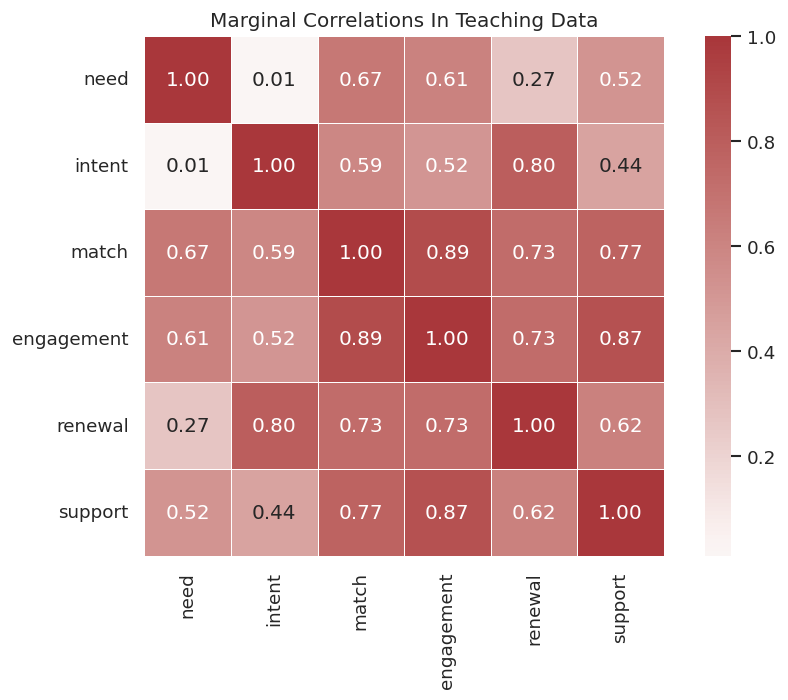

In [13]:
correlation_matrix = teaching_data.corr()
correlation_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Marginal Correlations In Teaching Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap shows associations along causal pathways, but it cannot distinguish direct causes from indirect paths. PC will use conditional independence, not just marginal correlation.

## Prepare The Data Matrix

Most `causal-learn` algorithms expect a NumPy array with rows as samples and columns as variables. We standardize the columns for a clean smoke test and keep the column order explicit.

In [14]:
scaler = StandardScaler()
data_matrix = scaler.fit_transform(teaching_data[node_names])

matrix_info = pd.DataFrame(
    {
        "position": list(range(len(node_names))),
        "variable": node_names,
        "mean_after_scaling": data_matrix.mean(axis=0),
        "std_after_scaling": data_matrix.std(axis=0),
    }
)
matrix_info.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_data_matrix_info.csv", index=False)
display(matrix_info)

,position,variable,mean_after_scaling,std_after_scaling
0,0,need,-0.0000,1.0000
1,1,intent,0.0000,1.0000
2,2,match,0.0000,1.0000
3,3,engagement,0.0000,1.0000
4,4,renewal,-0.0000,1.0000
5,5,support,0.0000,1.0000


The order in `node_names` matters because graph outputs refer to column positions. Passing node names into algorithms makes outputs much easier to read.

## PC Algorithm Smoke Test

The PC algorithm is a classic constraint-based discovery method. It starts from a dense graph, removes edges based on conditional independence tests, and then applies orientation rules.

Here we use the Fisher-Z test because the data are continuous and generated from a linear Gaussian setup. This is a friendly first test, not a claim that Fisher-Z is always appropriate.

In [15]:
if not CAUSAL_LEARN_AVAILABLE:
    raise ImportError("causal-learn is not available. Install causal-learn before running the PC smoke test.")

from causallearn.search.ConstraintBased.PC import pc

pc_result = pc(
    data_matrix,
    alpha=0.005,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=node_names,
)

pc_edges = [str(edge) for edge in pc_result.G.get_graph_edges()]
pc_edge_table = pd.DataFrame({"learned_edge": pc_edges})
pc_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_smoke_test_edges.csv", index=False)
display(pc_edge_table)

,learned_edge
0,need --- match
1,intent --> renewal
2,match --- engagement
3,engagement --> renewal
4,engagement --- support


The learned edges are the first proof that the environment is functional. The output may include directed edges and partially oriented or undirected edges, depending on what can be inferred from the data and assumptions.

## Inspect The Raw Graph Matrix

`causal-learn` graph objects store endpoint information in a matrix. The exact endpoint coding is library-specific, so the safest habit is to pair the matrix with readable edge strings.

In [16]:
pc_graph_matrix = pd.DataFrame(pc_result.G.graph, index=node_names, columns=node_names)
pc_graph_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_graph_matrix.csv")
display(pc_graph_matrix)

,need,intent,match,engagement,renewal,support
need,0,0,-1,0,0,0
intent,0,0,0,0,-1,0
match,-1,0,0,-1,0,0
engagement,0,0,-1,0,-1,-1
renewal,0,1,0,1,0,0
support,0,0,0,-1,0,0


The matrix is useful for programmatic evaluation, while the edge strings are easier for humans. Later notebooks will build more formal graph-conversion helpers.

## Convert The Learned Graph To A Simple Edge Table

For this first notebook, we convert the matrix into a simplified edge table with three edge types: directed, undirected, and partially marked. This is enough for a smoke-test comparison.

In [17]:
def simple_edge_table_from_matrix(graph_matrix, names):
    rows = []
    matrix = np.asarray(graph_matrix)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a = matrix[i, j]
            b = matrix[j, i]
            if a == 0 and b == 0:
                continue
            if a == -1 and b == 1:
                rows.append({"source": names[i], "target": names[j], "edge_type": "directed", "readable_edge": f"{names[i]} -> {names[j]}"})
            elif a == 1 and b == -1:
                rows.append({"source": names[j], "target": names[i], "edge_type": "directed", "readable_edge": f"{names[j]} -> {names[i]}"})
            elif a == -1 and b == -1:
                rows.append({"source": names[i], "target": names[j], "edge_type": "undirected", "readable_edge": f"{names[i]} -- {names[j]}"})
            else:
                rows.append({"source": names[i], "target": names[j], "edge_type": "partially_marked", "readable_edge": f"{names[i]} ({a},{b}) {names[j]}"})
    return pd.DataFrame(rows)

learned_edge_table = simple_edge_table_from_matrix(pc_result.G.graph, node_names)
learned_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_simplified_edge_table.csv", index=False)
display(learned_edge_table)

,source,target,edge_type,readable_edge
0,need,match,undirected,need -- match
1,intent,renewal,directed,intent -> renewal
2,match,engagement,undirected,match -- engagement
3,engagement,renewal,directed,engagement -> renewal
4,engagement,support,undirected,engagement -- support


The simplified table makes the graph output easier to compare to the known DAG. It also illustrates why graph-reading utilities are useful: raw graph objects are powerful, but not always report-ready.

## Draw The Learned PC Graph

This plot uses the same layout as the true DAG so the differences are easy to spot. Directed edges are shown with arrows; undirected or unresolved edges are shown as dashed lines.

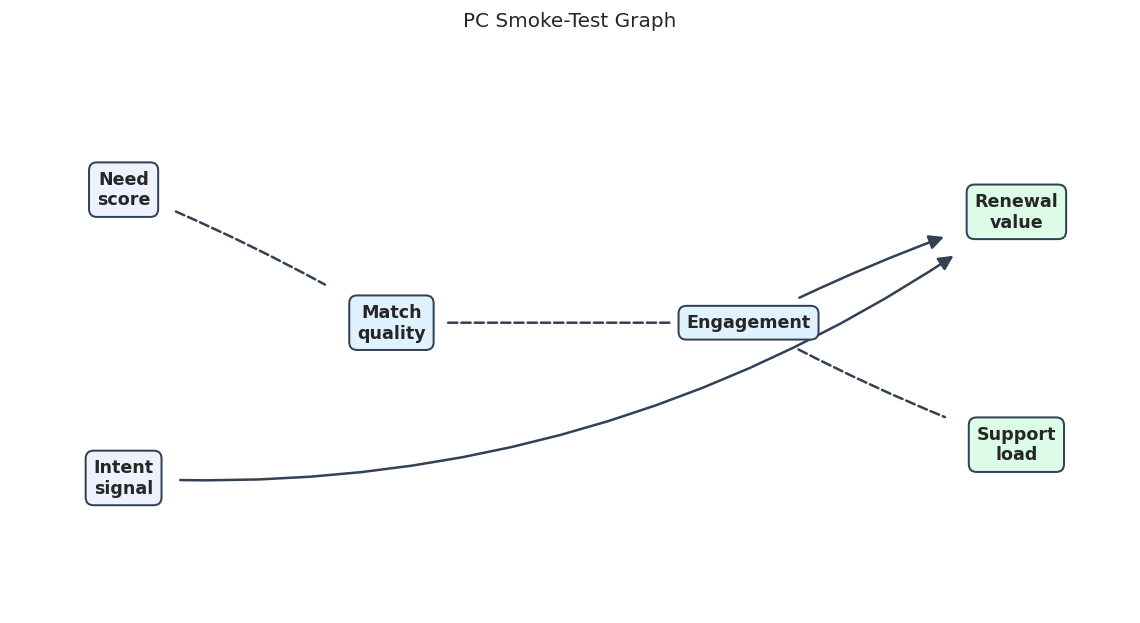

In [18]:
pc_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pc_smoke_test_graph.png"
draw_teaching_style_graph(learned_edge_table, "PC Smoke-Test Graph", pc_graph_path, edge_radii=edge_radii)

The learned graph should be close to the true graph because the data were designed for this method. Later notebooks will show less friendly conditions where recovery becomes weaker.

## Simple Graph Recovery Metrics

Because this is synthetic data, we know the true edges. The following metrics compare the learned skeleton and directed edges to the known graph. These are teaching metrics, not the only way to evaluate discovery quality.

In [19]:
def skeleton_set(edges):
    return {frozenset(edge) for edge in edges}

true_skeleton = skeleton_set(true_edges)
learned_skeleton = {frozenset((row.source, row.target)) for row in learned_edge_table.itertuples(index=False)}
true_directed = set(true_edges)
learned_directed = {
    (row.source, row.target)
    for row in learned_edge_table.itertuples(index=False)
    if row.edge_type == "directed"
}

skeleton_tp = len(true_skeleton & learned_skeleton)
skeleton_fp = len(learned_skeleton - true_skeleton)
skeleton_fn = len(true_skeleton - learned_skeleton)
directed_tp = len(true_directed & learned_directed)
directed_fp = len(learned_directed - true_directed)
directed_fn = len(true_directed - learned_directed)

metric_table = pd.DataFrame(
    [
        {
            "metric_family": "skeleton",
            "true_positive": skeleton_tp,
            "false_positive": skeleton_fp,
            "false_negative": skeleton_fn,
            "precision": skeleton_tp / max(skeleton_tp + skeleton_fp, 1),
            "recall": skeleton_tp / max(skeleton_tp + skeleton_fn, 1),
        },
        {
            "metric_family": "directed_edges",
            "true_positive": directed_tp,
            "false_positive": directed_fp,
            "false_negative": directed_fn,
            "precision": directed_tp / max(directed_tp + directed_fp, 1),
            "recall": directed_tp / max(directed_tp + directed_fn, 1),
        },
    ]
)
metric_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_recovery_metrics.csv", index=False)
display(metric_table)

,metric_family,true_positive,false_positive,false_negative,precision,recall
0,skeleton,5,0,1,1.0000,0.8333
1,directed_edges,2,0,4,1.0000,0.3333


Skeleton recovery is usually easier than orientation recovery. That is not a weakness of the metric; it reflects the fact that some directions are not identifiable from observational conditional independencies alone.

## Alpha Sensitivity

Constraint-based methods depend on the significance level used for conditional independence tests. The next cell reruns PC across several alpha values and records how the graph changes.

In [20]:
alpha_rows = []
alpha_values = [0.001, 0.005, 0.010, 0.050]
for alpha in alpha_values:
    result = pc(
        data_matrix,
        alpha=alpha,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=node_names,
    )
    edges = simple_edge_table_from_matrix(result.G.graph, node_names)
    learned_skeleton_alpha = {frozenset((row.source, row.target)) for row in edges.itertuples(index=False)}
    learned_directed_alpha = {
        (row.source, row.target)
        for row in edges.itertuples(index=False)
        if row.edge_type == "directed"
    }
    skeleton_tp_alpha = len(true_skeleton & learned_skeleton_alpha)
    directed_tp_alpha = len(true_directed & learned_directed_alpha)
    alpha_rows.append(
        {
            "alpha": alpha,
            "n_edges": len(edges),
            "n_directed_edges": int((edges["edge_type"] == "directed").sum()) if len(edges) else 0,
            "skeleton_precision": skeleton_tp_alpha / max(len(learned_skeleton_alpha), 1),
            "skeleton_recall": skeleton_tp_alpha / max(len(true_skeleton), 1),
            "directed_precision": directed_tp_alpha / max(len(learned_directed_alpha), 1),
            "directed_recall": directed_tp_alpha / max(len(true_directed), 1),
            "edge_list": "; ".join(edges["readable_edge"].tolist()) if len(edges) else "no edges",
        }
    )

alpha_sensitivity = pd.DataFrame(alpha_rows)
alpha_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_alpha_sensitivity.csv", index=False)
display(alpha_sensitivity)

,alpha,n_edges,n_directed_edges,skeleton_precision,skeleton_recall,directed_precision,directed_recall,edge_list
0,0.0010,5,2,1.0000,0.8333,1.0000,0.3333,need -- match; intent -> renewal; match -- eng...
1,0.0050,5,2,1.0000,0.8333,1.0000,0.3333,need -- match; intent -> renewal; match -- eng...
2,0.0100,5,2,1.0000,0.8333,1.0000,0.3333,need -- match; intent -> renewal; match -- eng...
3,0.0500,5,2,1.0000,0.8333,1.0000,0.3333,need -- match; intent -> renewal; match -- eng...


Even in a friendly setting, alpha is a modeling choice. A responsible discovery workflow reports sensitivity rather than presenting one graph as if it were inevitable.

## Plot Alpha Sensitivity

The next figure summarizes how precision, recall, and edge count change with alpha. This is a compact way to spot brittle graph recovery.

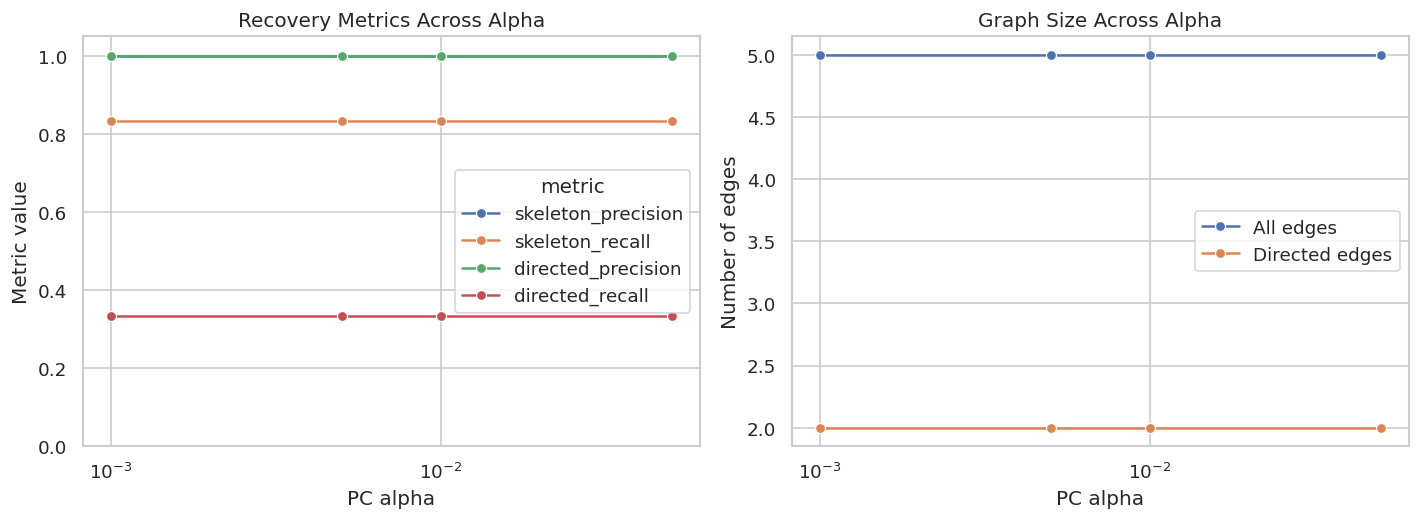

In [21]:
alpha_metric_plot = alpha_sensitivity.melt(
    id_vars=["alpha", "n_edges", "n_directed_edges"],
    value_vars=["skeleton_precision", "skeleton_recall", "directed_precision", "directed_recall"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=alpha_metric_plot, x="alpha", y="value", hue="metric", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Recovery Metrics Across Alpha")
axes[0].set_xlabel("PC alpha")
axes[0].set_ylabel("Metric value")

sns.lineplot(data=alpha_sensitivity, x="alpha", y="n_edges", marker="o", label="All edges", ax=axes[1])
sns.lineplot(data=alpha_sensitivity, x="alpha", y="n_directed_edges", marker="o", label="Directed edges", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Graph Size Across Alpha")
axes[1].set_xlabel("PC alpha")
axes[1].set_ylabel("Number of edges")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pc_alpha_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

In this small example the graph is fairly stable, which is reassuring. In real data, a graph that changes dramatically across reasonable alpha values should be reported as unstable.

## A Tiny Independence-Test Intuition Check

PC is built from conditional independence tests. This cell gives a simple intuition check by comparing marginal and conditional relationships in the teaching data.

In [22]:
def residualize(target, controls):
    controls = np.asarray(controls)
    if controls.ndim == 1:
        controls = controls.reshape(-1, 1)
    controls = np.column_stack([np.ones(len(controls)), controls])
    beta = np.linalg.lstsq(controls, target, rcond=None)[0]
    return target - controls @ beta

need_values = teaching_data["need"].to_numpy()
intent_values = teaching_data["intent"].to_numpy()
match_values = teaching_data["match"].to_numpy()

marginal_corr = stats.pearsonr(need_values, intent_values).statistic
conditional_corr_given_match = stats.pearsonr(
    residualize(need_values, match_values),
    residualize(intent_values, match_values),
).statistic
conditional_corr_given_match_engagement = stats.pearsonr(
    residualize(need_values, teaching_data[["match", "engagement"]].to_numpy()),
    residualize(intent_values, teaching_data[["match", "engagement"]].to_numpy()),
).statistic

independence_demo = pd.DataFrame(
    [
        {"relationship": "corr(need, intent)", "value": marginal_corr, "why_it_matters": "Root variables are marginally close to independent in the data-generating process."},
        {"relationship": "corr(need, intent | match)", "value": conditional_corr_given_match, "why_it_matters": "Conditioning on a collider can create dependence."},
        {"relationship": "corr(need, intent | match, engagement)", "value": conditional_corr_given_match_engagement, "why_it_matters": "Conditioning on descendants of a collider can also change dependence patterns."},
    ]
)
independence_demo.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_independence_intuition.csv", index=False)
display(independence_demo)

,relationship,value,why_it_matters
0,"corr(need, intent)",0.0102,Root variables are marginally close to indepen...
1,"corr(need, intent | match)",-0.6398,Conditioning on a collider can create dependence.
2,"corr(need, intent | match, engagement)",-0.6394,Conditioning on descendants of a collider can ...


This small table shows why causal discovery is more subtle than correlation screening. Conditioning choices can create or remove associations depending on the graph structure.

## Practical Startup Checklist

Before starting any causal discovery analysis, run a short checklist. This notebook creates a reusable version for the rest of the series.

In [23]:
startup_checklist = pd.DataFrame(
    [
        ("Data timing", "Confirm every variable is measured at the intended time and does not include future leakage."),
        ("Variable roles", "Decide whether variables are observed causes, outcomes, mediators, selection variables, or environment indices."),
        ("Data type", "Choose methods and tests that match continuous, discrete, mixed, or time-series data."),
        ("Hidden confounding risk", "Decide whether causal sufficiency is plausible; if not, consider FCI-style methods."),
        ("Sample size", "Check whether conditional independence tests or score searches are realistic for the number of variables."),
        ("Domain constraints", "Collect required or forbidden edges before looking at results when possible."),
        ("Sensitivity", "Plan to vary alpha, scores, bootstrap samples, or algorithm families."),
        ("Reporting", "State that the output is a candidate graph unless stronger validation is available."),
    ],
    columns=["check", "why_it_matters"],
)
startup_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_startup_checklist.csv", index=False)
display(startup_checklist)

,check,why_it_matters
0,Data timing,Confirm every variable is measured at the inte...
1,Variable roles,"Decide whether variables are observed causes, ..."
2,Data type,Choose methods and tests that match continuous...
3,Hidden confounding risk,Decide whether causal sufficiency is plausible...
4,Sample size,Check whether conditional independence tests o...
5,Domain constraints,Collect required or forbidden edges before loo...
6,Sensitivity,"Plan to vary alpha, scores, bootstrap samples,..."
7,Reporting,State that the output is a candidate graph unl...


The checklist is intentionally conservative. Causal discovery is powerful, but it can also produce very confident-looking graphs from weak assumptions.

## Output Inventory

This cell lists the artifacts created by notebook 00. The list is useful when the notebook is used as a setup check for the rest of the tutorial series.

In [24]:
output_inventory = pd.DataFrame(
    {
        "artifact_type": ["figures", "tables"],
        "count_with_prefix_00": [
            len(list(FIGURE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))),
            len(list(TABLE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))),
        ],
        "folder": [str(FIGURE_DIR), str(TABLE_DIR)],
    }
)
output_inventory.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_output_inventory.csv", index=False)
display(output_inventory)

,artifact_type,count_with_prefix_00,folder
0,figures,4,/home/apex/Documents/ranking_sys/notebooks/tut...
1,tables,21,/home/apex/Documents/ranking_sys/notebooks/tut...


The output inventory confirms that the notebook saved both teaching figures and reusable tables. This is the same artifact pattern used across the other tutorial folders.

## Final Takeaways

Notebook 00 should leave you with four core ideas:

- `causal-learn` is for learning candidate graph structure from data.
- Method choice is assumption choice: PC, FCI, GES, LiNGAM, ANM, and other methods answer different discovery problems.
- Partially oriented graphs are normal because observational data often cannot identify every direction.
- Every discovered graph needs sensitivity checks and domain review before it supports effect estimation or decisions.

The next notebook should focus on graph objects, DAGs, CPDAGs, PAGs, edge marks, and graph evaluation metrics in more depth.